<a href="https://colab.research.google.com/github/letum-tut/letum-tut/blob/main/analysis/titanic_eda/Titanic_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#0. SETUP - zawsze uruchomić
- wczytywanie bibliotek i konfiguracja ścieżek
- montowanie dysku
- funkcje zapisu i odczytu



##0.1 Wczytywanie bibliotek i konfiguracja ścieżek

In [ ]:
## 0. SETUP: Importy Bibliotek i Konfiguracja

import os
import re
import pandas as pd
from datetime import datetime
from google.colab import drive
from google.colab import files

# Importy dla modelowania i analizy
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# KONFIGURACJA ŚCIEŻEK
# Główna ścieżka do katalogu z danymi na Drive
# Używana we wszystkich funkcjach save/load
DATA_DIR = '/content/drive/MyDrive/datasets/'


##0.2. Montowanie Dysku Google

Podłączamy Dysk Google do środowiska Google Colab, aby uzyskać dostęp do plików zapisanych w chmurze.Po montażu pliki z Dysku będą dostępne pod ścieżką `/content/drive/MyDrive/`.




In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


##0.3. Zapisywania danych - funkcje pomocnicze

Każdy zapis tworzy osobną wersję pliku w Google Drive aby utrzymać porządek, bezpieczeństwo i możliwość cofnięcia się do dowolnego etapu pracy z danymi.

<br>

###**Kiedy używać funkcji `save_to_drive()` - przykłady**

<br>

| Etap projektu | Co robisz | Nazwa pliku | Przykład wywołania | Komentarz |
|----------------|------------|--------------|---------------------|------------|
| **Po wczytaniu danych surowych** | Kopia bezpieczeństwa oryginału | `titanic_raw` | `save_to_drive(df, 'titanic_raw', comment='oryginał Kaggle')` | Nigdy nie nadpisuj danych źródłowych |
| **Po wstępnym czyszczeniu** | Usuwanie braków, zmiana typów | `titanic_clean` | `save_to_drive(df, 'titanic_clean', comment='age imputacja medianą, drop deck')` | Możesz zapisywać wiele razy – timestamp gwarantuje unikalność |
| **Po EDA (analizie danych)** | Dane gotowe do modelowania | `titanic_eda_ready` | `save_to_drive(df, 'titanic_eda_ready', version='v1', comment='EDA zakończona')` | Użyj `version` przy ważnych milestone’ach |
| **Po feature engineering** | Dodanie nowych kolumn | `titanic_features` | `save_to_drive(df, 'titanic_features', comment='dodane feature: family_size, title')` | Dobrze mieć snapshot po każdej większej zmianie |
| **Po podziale train/test** | Podział na zbiory | `titanic_train`, `titanic_test` | `save_to_drive(train_df, 'titanic_train', comment='podział 80/20')` | Pomaga odtworzyć proces |
| **Po modelowaniu** | Wyniki / predykcje | `titanic_predictions` | `save_to_drive(pred_df, 'titanic_predictions', comment='model logistic regression')` | Archiwizuj też wyniki modeli |

<br>

**Wskazówki organizacyjne**
- **Dodawaj komentarze** do każdego zapisu (nawet krótko: co zmieniłeś lub przetestowałeś).  
- Każdy projekt ma osobny folder w `datasets/` (np. `datasets/titanic`).  
- Lepiej zapisać częściej niż za rzadko – timestamp w nazwie zapobiega nadpisaniu.  
- Po każdym „większym etapie” (np. EDA, Feature Engineering) zapisz wersję.  
- Plik historii (`save_history.txt`) można potraktować jak **mini dziennik pracy** do raportu.  

<br>

**Mini skrót (pro workflow)**

raw → clean → eda → features → model

Każdy krok = nowy zapis.  

In [ ]:
def save_to_drive(df: pd.DataFrame,
                  name: str,
                  project: str = 'titanic',
                  add_date: bool = True,
                  version: str = None,
                  comment: str = None) -> str:
    """
    Zapisuje DataFrame do Google Drive w folderze projektu i dopisuje wpis do save_history.txt.
    - df: pandas DataFrame
    - name: nazwa bazowa pliku (np. 'titanic_clean')
    - project: podfolder projektu (np. 'titanic')
    - add_date: jeżeli True -> dodaje timestamp do nazwy pliku
    - version: np. 'v01' — jeśli podane, użyje tego zamiast timestampu
    - comment: opcjonalny tekst, który zostanie zapisany w historii (np. 'po EDA')
    """
    # 1. przygotuj folder projektu
    base_dir = os.path.join(DATA_DIR, project)
    os.makedirs(base_dir, exist_ok=True)

    # 2. przygotuj nazwę pliku
    if version:
        filename = f"{name}_{version}.csv"
    elif add_date:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = f"{name}_{timestamp}.csv"
    else:
        filename = f"{name}.csv"

    # 3. pełna ścieżka docelowa
    path = os.path.join(base_dir, filename)

    # 4. zapis pliku CSV (nadpisze jeśli istnieje ten exact path)
    df.to_csv(path, index=False)

    # 5. dopisz wpis do pliku historii
    history_path = os.path.join(base_dir, 'save_history.txt')
    rows, cols = df.shape
    now_iso = datetime.now().isoformat(sep=' ', timespec='seconds')
    comment_str = f" | {comment}" if comment else ""
    log_line = f"{now_iso} | {filename} | rows:{rows} | cols:{cols}{comment_str}\n"

    # append do pliku historii (utworzy plik jeśli nie istnieje)
    with open(history_path, 'a', encoding='utf-8') as f:
        f.write(log_line)

    print(f"Dane zapisane jako: {path}")
    print(f"Historia zapisu dopisana do: {history_path}")
    return path

# Dodatkowe helpery
def read_save_history(project='titanic'):
    """Zwraca listę linii z save_history.txt (jeśli istnieje)."""
    history_path = os.path.join(DATA_DIR, project, 'save_history.txt')
    if not os.path.exists(history_path):
        print("Brak pliku historii dla projektu:", project)
        return []
    with open(history_path, 'r', encoding='utf-8') as f:
        lines = [ln.strip() for ln in f.readlines()]
    return lines

def list_project_files(project='titanic'):
    """Wypisuje pliki w folderze projektu."""
    base_dir = os.path.join(DATA_DIR, project)
    if not os.path.exists(base_dir):
        print("Folder projektu nie istnieje:", base_dir)
        return []
    return os.listdir(base_dir)

# zapis z automatycznym timestampem i komentarzem
# save_to_drive(df, 'titanic_clean', project='titanic', add_date=True, comment='po usunięciu deck; imputacja age medianą')

# zapis z wersją v1 (np. po zakończonej EDA)
# save_to_drive(df, 'titanic_clean', project='titanic', add_date=False, version='v1', comment='EDA ready')

# sprawdź historię zapisów
# for ln in read_save_history('titanic'):
#     print(ln)

# lista plików w folderze projektu
# print(list_project_files('titanic'))


##0.4. Wczytywanie Ścieżki do Najnowszej Wersji Danych - funkcja pomocnicza

Funkcja **`get_latest_data_version`** automatyzuje proces wczytywania danych, eliminując konieczność ręcznego edytowania ścieżek dostępu. Zapewnia, że zawsze zaczynasz pracę od najbardziej aktualnego punktu kontrolnego (checkpointu).

<br>

###**`get_latest_data_version(project_name, data_type)`**


Zwraca pełną ścieżkę do najnowszej wersji pliku CSV, na podstawie konwencji nazewnictwa: `[project_name]_[data_type]_[YYYYMMDD_HHMMSS].csv`.

<br>

| Argument | Typ | Opis | Przykład |
| :--- | :--- | :--- | :--- |
| `project_name` | `str` | Główna nazwa projektu (np. `titanic`). | `'titanic'` |
| `data_type` | `str` | Etap przetwarzania danych (checkpoint), np. `raw`, `clean`, `eda_ready`). | `'clean'` |

<br>

**Zasada Działania:**

1.  Tworzy wzorzec wyszukiwania (np. `titanic_clean`).
2.  Przeszuka folder, filtruje pliki i sortuje je alfabetycznie.
3.  Dzięki formatowi znacznika czasowego (YYYYMMDD\_HHMMSS), **ostatni plik na liście jest najnowszy**.
4.  Zwraca pełną ścieżkę, gotową do użycia przez `pd.read_csv()`.

<br>

**Przykładowe użycie:**

```python
# Użyj funkcji, aby znaleźć najnowszą wyczyszczoną wersję
latest_path = get_latest_data_version(project_name='titanic', data_type='clean')

if latest_path:
    # Wczytaj dane do głównego DataFrame
    df_current = pd.read_csv(latest_path)
    print(f"Dane wczytane. Nowa praca zaczyna się od {len(df_current)} wierszy.")
    df = df_current # Opcjonalnie: Ustawienie df jako głównej zmiennej roboczej
else:
    print("Nie znaleziono pliku 'clean'. Wymagane ręczne wczytanie 'raw'.")
```


In [ ]:
def get_latest_data_version(project_name: str, data_type: str) -> str or None:
    """
    Znajduje najnowszą wersję pliku danych w folderze na Google Drive.

    Argumenty:
      project_name (str): Nazwa projektu, np. 'titanic'.
      data_type (str): Typ danych (checkpoint), np. 'raw', 'clean', 'eda_ready'.

    Zwraca:
      str: Pełna ścieżka do najnowszego pliku CSV.
    """
    base_dir = os.path.join(DATA_DIR, project_name)

    # 1. Określenie wzorca nazwy pliku
    # Oczekiwany format: titanic_clean_YYYYMMDD_HHMMSS.csv
    prefix = f"{project_name}_{data_type}"

    # 2. Lista wszystkich plików w katalogu
    try:
        all_files = os.listdir(base_dir)
    except FileNotFoundError:
        print(f"Błąd: Nie znaleziono katalogu bazowego: {base_dir}")
        return None
    except Exception as e:
        print(f"Wystąpił nieoczekiwany błąd: {e}")
        return None

    # 3. Filtrowanie plików, które pasują do prefiksu i mają timestamp
    relevant_files = [
        f for f in all_files
        if f.startswith(prefix) and f.endswith('.csv')
    ]

    if not relevant_files:
        print(f"Nie znaleziono plików dla typu: '{project_name}-{data_type}'")
        return None

    # 4. Znajdowanie pliku z najnowszym timestampem
    # Sortowanie plików po nazwie (alfa-numeryczne), dzięki temu, że timestamp jest
    # w formacie YYYYMMDD_HHMMSS, ostatni plik na liście będzie najnowszy.
    relevant_files.sort()
    latest_file_name = relevant_files[-1]

    # 5. Zwrócenie pełnej ścieżki
    latest_path = os.path.join(base_dir, latest_file_name)
    print(f"Znaleziono najnowszą wersję: {latest_file_name}")

    return latest_path

# 1. Wczytanie danych Titanic z Google Drive lub z pliku lokalnego


**Co robi kod:**
- Ustala ścieżkę do pliku `titanic-train.csv` na Google Drive.
- Sprawdza, czy plik istnieje:
  - Jeśli tak → wczytuje dane do `DataFrame` (`df`) i wyświetla podstawowe informacje (liczba wierszy i kolumn).
  - Jeśli nie → prosi użytkownika o ręczne wgranie pliku przez okno `files.upload()` i automatycznie go wczytuje.


In [ ]:
## 1. Wczytanie Danych Titanic z Google Drive lub z pliku lokalnego

# Używamy DATA_DIR, aby zapewnić spójność ścieżek
PROJECT_NAME = 'titanic'
RAW_DATA_FILENAME = 'titanic-train.csv'
titanic_path = os.path.join(DATA_DIR, PROJECT_NAME, RAW_DATA_FILENAME)

print(f"Oczekiwana ścieżka pliku surowego: {titanic_path}")

if os.path.exists(titanic_path):
    print("\nPlik znaleziony! Wczytuję dane...")
    df = pd.read_csv(titanic_path)
    print(f"Liczba wierszy: {len(df):,} | Liczba kolumn: {len(df.columns)}")

    # Zapisujemy pierwszą wersję jako checkpoint 'raw'
    # To jest moment, w którym od razu tworzysz checkpoint najnowszych surowych danych.
    save_to_drive(df, name=f'{PROJECT_NAME}_raw', add_date=True, comment="Początkowe wczytanie surowych danych treningowych")

else:
    print("\nPlik nie został znaleziony!")
    print(f"Oczekiwano pliku w: {titanic_path}")
    print("Jeśli chcesz, wgraj go teraz ręcznie:")

    # Kod do ręcznego wgrania pliku
    uploaded = files.upload()
    for fn in uploaded.keys():
        df = pd.read_csv(fn)
        print(f"Wczytano {fn}, {len(df):,} wierszy.")

        # Po ręcznym wczytaniu też zapisz jako 'raw'
        save_to_drive(df, name=f'{PROJECT_NAME}_raw', add_date=True, comment="Ręczne wgranie surowych danych treningowych")

Oczekiwana ścieżka pliku surowego: /content/drive/MyDrive/datasets/titanic/titanic-train.csv

Plik znaleziony! Wczytuję dane...
Liczba wierszy: 891 | Liczba kolumn: 12
Dane zapisane jako: /content/drive/MyDrive/datasets/titanic/titanic_raw_20251117_170624.csv
Historia zapisu dopisana do: /content/drive/MyDrive/datasets/titanic/save_history.txt


###Zapisanie oryginalnego pliku.

In [ ]:
save_to_drive(df, 'titanic_raw', comment='oryginał Kaggle')

Dane zapisane jako: /content/drive/MyDrive/datasets/titanic/titanic_raw_20251117_170634.csv
Historia zapisu dopisana do: /content/drive/MyDrive/datasets/titanic/save_history.txt


'/content/drive/MyDrive/datasets/titanic/titanic_raw_20251117_170634.csv'

#2. Wstępna Analiza Danych (EDA)

## 2.1. Wstępna eksploracja danych — struktura, statystyki

Na tym etapie sprawdzamy podstawowe informacje o zbiorze Titanic, aby zrozumieć jego strukturę i jakość danych.

<br>

**Co robi kod:**
* `df.info()` — wyświetla typy kolumn, liczbę niepustych wartości i ogólną strukturę DataFrame. Pomaga szybko wykryć kolumny z brakami oraz określić rozmiar zbioru.
* `df.describe()` — generuje statystyki opisowe (średnia, odchylenie, min, max, kwartyle) dla kolumn numerycznych.

<br>

**Zastosowanie:**
* Pierwszy rzut oka na dane: typy, rozmiar.
* Pomaga w decyzjach dotyczących imputacji, usuwania kolumn lub normalizacji.

<br>

**Uwagi:**
Dla dużych zbiorów można skrócić opis do kluczowych kolumn, np. `df[['Age', 'Fare']].describe()`.

<br>

**Opis kolumn:**
- survival:	0 = No, 1 = Yes
- pclass: 1 = 1st, 2 = 2nd, 3 = 3rd
  - a proxy for socio-economic status (SES): 1st = Upper, 2nd = Middle, 3rd = Lower
- sex
- age: in years
  - age is fractional if less than 1. If the age is estimated, is it in the form of xx.5
- sibsp: 	# of siblings / spouses aboard the Titanic
  - The dataset defines family relations in this way:
    - Sibling = brother, sister, stepbrother, stepsister
    - Spouse = husband, wife (mistresses and fiancés were ignored)
- parch: 	# of parents / children aboard the Titanic
  - the dataset defines family relations in this way:
    - Parent = mother, father
    - Child = daughter, son, stepdaughter, stepson
    - Some children travelled only with a nanny, therefore parch=0 for them.
- ticket: 	Ticket number
- fare: 	Passenger fare
- cabin: 	Cabin number
- embarked: 	Port of Embarkation 	C = Cherbourg, Q = Queenstown, S = Southampton

In [ ]:
# 2.1. Sprawdzenie typów danych i brakujących wartości (info)
df.info()

print("\n" + "="*50 + "\n")

# Sprawdzenie statystyk opisowych dla kolumn numerycznych (describe)
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB




,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 2.2. Analiza brakujących danych — procentowy udział i ranking kolumn

Identyfikujemy braki i sprawdzamy, jak duży procent danych brakuje w każdej kolumnie.
To ułatwia podjęcie decyzji, które kolumny warto uzupełnić, a które ewentualnie usunąć.

<br>

**Co robi kod:**
1.  Oblicza liczbę i procent brakujących wartości w każdej kolumnie.
2.  Tworzy czytelną tabelę (`missing_data`) zawierającą bezwzględną liczbę braków (`missing_values`) oraz ich udział w procentach (`missing_percent`).
3.  Sortuje tabelę, aby na szczycie znalazły się kolumny z największymi brakami (np. `Cabin`, `Age`).

<br>

**Zastosowanie:**
* Ułatwia szybkie wychwycenie problematycznych kolumn (np. z ponad 30% braków).
* Przydatne do dokumentowania jakości danych jeszcze przed ich czyszczeniem.

<br>

**Uwagi:**
* **Decyzje:** `Cabin` (ponad 77% braków) jest kandydatem do usunięcia lub ekstrakcji tylko pierwszego znaku (`Deck`). `Age` (ok. 20% braków) wymaga imputacji.
* Warto dodać wizualizację braków danych (`sns.heatmap(df.isnull())`) w następnym etapie EDA.

In [ ]:
# 2.2. Tworzenie tabeli z brakującymi danymi

# Tworzenie DataFrame zawierającego liczbę i procent braków
missing_data = pd.DataFrame({
    'missing_values': df.isnull().sum(),
    'missing_percent': df.isnull().sum() / len(df) * 100
})

# Sortowanie malejąco, aby zobaczyć najgorsze kolumny na górze
missing_data_sorted = missing_data.sort_values(by='missing_percent', ascending=False)

# Wyświetlenie tylko kolumn, w których występują braki (pomijając te z 0%)
missing_data_sorted[missing_data_sorted['missing_values'] > 0]

,missing_values,missing_percent
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467


###Zapisanie pliku.

In [ ]:
save_to_drive(df, 'titanic_raw', comment='wstępna analiza')

Dane zapisane jako: /content/drive/MyDrive/datasets/titanic/titanic_raw_20251117_170655.csv
Historia zapisu dopisana do: /content/drive/MyDrive/datasets/titanic/save_history.txt


'/content/drive/MyDrive/datasets/titanic/titanic_raw_20251117_170655.csv'

###Wczytanie pliku.

In [ ]:
# Użyj funkcji, aby znaleźć najnowszą wersję 'raw'
latest_path = get_latest_data_version(
    project_name='titanic',
    data_type='raw'
)

if latest_path:
    # Wczytaj dane do głównego DataFrame
    df_current = pd.read_csv(latest_path)
    print(f"Dane wczytane.")
    print(f"Liczba wierszy: {len(df_current)} | Kolumn: {len(df_current.columns)}")
    df = df_current # Opcjonalnie: Ustawienie df jako głównej zmiennej roboczej
else:
    print("Nie znaleziono pliku 'clean'. Wymagane ręczne wczytanie 'raw'.")


Znaleziono najnowszą wersję: titanic_raw_20251117_170655.csv
Dane wczytane.
Liczba wierszy: 891 | Kolumn: 12


#3. Czyszczenie danych

**Braki w kolumnach:**
- Cabin - braki w kolumnie ~77%
- Age - braki w kolumnie ~20%
- Embarked - braki w kolumnie ~0.22%


## 3.1. Czyszczenie Danych: Analiza i Ekstrakcja Pokładu (Deck)

Kolumna `Cabin` z uwagi na ogromną liczbę braków byłaby zwykle usuwana. Jednakże, ponieważ wartości w tej kolumnie zawierają informację o **pokładzie** (pierwsza litera, np. 'C123' to pokład C), możemy z niej wyodrębnić cenną cechę kategoryczną — `Deck`.

**Co robi kod 1 i 2 (Analiza):**
* **Kod 1:** Sprawdza unikalne, niepuste wartości, aby potwierdzić format (`Litera-Liczba`).
* **Kod 2:** Weryfikuje liczebność pasażerów na poszczególnych pokładach (A, B, C, D, E, F, G, T) i potwierdza, że informacja jest użyteczna.

In [ ]:
# 3.1. Analiza struktury kolumny 'Cabin' przed ekstrakcją

# 1. Analiza pierwszych 10 niepustych wartości w kolumnie 'Cabin'
print("### 10 unikalnych przykładów wartości w kolumnie 'Cabin' (niepuste) ###")
print(df['Cabin'].dropna().unique()[:10])

print("\n" + "="*50 + "\n")

# 2. Sprawdzenie liczebności kabin na każdym pokładzie (pierwsza litera)
print("### Unikalne Pokłady (Deck) i ich Liczebność ###")
# .str[0] - pobiera pierwszą literę (pokład)
# .value_counts().sort_index() - liczy wystąpienia i sortuje alfabetycznie
print(df['Cabin'].dropna().str[0].value_counts().sort_index())

### 10 unikalnych przykładów wartości w kolumnie 'Cabin' (niepuste) ###
['C85' 'C123' 'E46' 'G6' 'C103' 'D56' 'A6' 'C23 C25 C27' 'B78' 'D33']


### Unikalne Pokłady (Deck) i ich Liczebność ###
Cabin
A    15
B    47
C    59
D    33
E    32
F    13
G     4
T     1
Name: count, dtype: int64


## 3.2. Ekstrakcja Cechy 'Deck' i Imputacja Braków

<br>

**Wniosek:** Zamiast usuwać kolumnę `Cabin`, wyodrębniamy nową cechę `Deck`, którą następnie będziemy mogli zaimputować.

<br>

**Co robi kod:**
1.  Tworzy nową kolumnę `df['Deck']`, pobierając pierwszą literę z `Cabin`.
2.  Automatycznie generuje wartości `NaN` dla wierszy, gdzie `Cabin` było puste.
3.  Wyświetla unikalne wartości wraz z `NaN`, aby zobaczyć, ile braków czeka na imputację.
4. Zastępuje wszystkie braki (`NaN`) nową kategorią 'U' (Unknown/Nieznany)

In [ ]:
# 1. Tworzymy nową kolumnę 'Deck' biorąc pierwszą literę z 'Cabin'
# Ta operacja tworzy wartości 'NaN' wszędzie tam, gdzie 'Cabin' było brakiem.
df['Deck'] = df['Cabin'].str[0]

print("### Unikalne Pokłady (Deck) i ich Liczebność (z NaN) ###")
# value_counts(dropna=False) uwzględnia i wyświetla braki (NaN)
print(df['Deck'].value_counts(dropna=False))

# 2. Imputacja brakujących wartości 'NaN' w kolumnie 'Deck'
# Zastąpienie wszystkich braków (NaN) nową kategorią 'U' (Unknown/Nieznany)
df['Deck'] = df['Deck'].fillna('U')

print("\n### Unikalne Pokłady (Deck) i ich Liczebność po Imputacji (U) ###")
print(df['Deck'].value_counts(dropna=False))


### Unikalne Pokłady (Deck) i ich Liczebność (z NaN) ###
Deck
NaN    687
C       59
B       47
D       33
E       32
A       15
F       13
G        4
T        1
Name: count, dtype: int64

### Unikalne Pokłady (Deck) i ich Liczebność po Imputacji (U) ###
Deck
U    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64


## 3.3. Ekstrakcja Tytułów Osobistych (`Title`)

Kolumna `Age` ma około 20% braków. Zamiast imputacji ogólną medianą (ze wszystkich pasażerów), wykorzystamy kolumnę `Name` do wydobycia tytułów (np. 'Mr.', 'Mrs.', 'Master'), które silnie korelują z wiekiem i statusem społecznym. To pozwoli na **bardziej precyzyjną imputację medianą grupową**.

<br>

**Co robi kod:**
1.  **Wyrażenie Regularne (`r' ([A-Za-z]+)\.'`):** Wyszukuje ciąg liter, który znajduje się po spacji i przed kropką (np. `Buss, Miss. Beryl` → `Miss`).
2.  Tworzy nową kolumnę `df['Title']`.
3.  Wyświetla liczebność wystąpień każdego tytułu.

<br>

**Zastosowanie:**
* Tworzy cechę kategoryczną, która silnie koreluje z wiekiem i statusem, co jest kluczowe dla dalszej analizy i imputacji.

In [ ]:
# Użycie wyrażenia regularnego do wydobycia tytułu (np. Mr, Miss, Mrs, itp.)
# Wyrażenie ' ([A-Za-z]+)\.' znajduje ciąg liter po spacji i przed kropką.
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

print("### Liczba wystąpień i Przykłady Tytułów ###")
print(df['Title'].value_counts())

### Liczba wystąpień i Przykłady Tytułów ###
Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


## 3.4. Statystyki Wieku (`Age`) Względem Tytułu i Klasy (`Pclass`)

Przed imputacją braków w kolumnie `Age`, analizujemy medianę wieku w obrębie każdej grupy zdefiniowanej przez `Title` oraz `Pclass`.

<br>

**Co robi kod:**
* `df.groupby(['Title', 'Pclass'])['Age']` — Dzieli dane na grupy i koncentruje się na kolumnie `Age`.
* `.agg(['count', 'mean', 'median'])` — Oblicza liczbę pasażerów, średnią i medianę wieku dla każdej grupy.

<br>

**Wniosek z analizy:**
* Mediana wieku różni się znacząco w zależności od tytułu i klasy (np. `Master` ma medianę 4 lata, a `Mr` z 1. klasy ma inną niż `Mr` z 3. klasy).
* To uzasadnia decyzję o **imputacji medianą specyficzną dla każdego tytułu/klasy**, co jest dokładniejsze niż imputacja ogólną medianą.

In [ ]:
# df.groupby(['Title', 'Pclass']) - Dzieli cały zbiór danych (df) na grupy w oparciu o unikalne wartości w kolumnie Title i Pclass.
# ['Age'] - Zastosowanie dalszych operacji ogranicza się tylko do kolumny Age w ramach każdej utworzonej grupy.
# .agg(['count', 'mean', 'median']) - Stosuje wiele funkcji agregujących jednocześnie do kolumny Age w każdej grupie Title.
# .sort_values(by='count', ascending=False) - Sortuje wynikowy DataFrame malejąco (ascending=False) według kolumny count.
title_age_stats = df.groupby(['Title', 'Pclass'])['Age'].agg(['count', 'mean', 'median']).sort_values(by='count', ascending=False)
print(title_age_stats)

                 count       mean  median
Title    Pclass                          
Mr       3         229  28.724891    26.0
         1          87  41.580460    40.0
         2          82  32.768293    31.0
Miss     3          69  16.123188    18.0
         1          45  30.000000    30.0
Mrs      2          41  33.682927    32.0
         1          34  40.882353    41.5
         3          33  33.515152    31.0
Miss     2          32  22.390625    24.0
Master   3          24   5.350833     4.0
         2           9   2.258889     1.0
Rev      2           6  43.166667    46.5
Dr       1           4  43.750000    46.5
Master   1           3   5.306667     4.0
Mlle     1           2  24.000000    24.0
Dr       2           2  38.500000    38.5
Col      1           2  58.000000    58.0
Major    1           2  48.500000    48.5
Jonkheer 1           1  38.000000    38.0
Lady     1           1  48.000000    48.0
Don      1           1  40.000000    40.0
Countess 1           1  33.000000 

## 3.5. Imputacja Braków w `Age` — Strategia Mediany Grupowej

Po wydobyciu i uporządkowaniu tytułów, możemy przejść do imputacji brakujących wartości w kolumnie `Age`. Nasza strategia jest dwuetapowa, co minimalizuje błąd w predykcji:

1.  **Uporządkowanie Tytułów (Czyszczenie):** Najpierw ujednolicamy rzadkie i podobne tytuły (np. `Mlle` do `Miss`, rzadkie rangą do `Rare`), aby zwiększyć statystyczną moc pozostałych grup.
2.  **Imputacja Mediana Grupą:**
    * Dla większości pasażerów (`Mr`, `Mrs`, `Miss`, `Rare`) braki są uzupełniane **medianą wieku** wyliczoną dla ich specyficznej grupy: **Tytuł** w połączeniu z **Klasą Podróży (`Pclass`)**.
    * **Wyjątek (`Master`):** Tytuł `Master` (młodzi chłopcy) jest traktowany oddzielnie. Ich wiek nie zależał silnie od klasy, dlatego braki w tej grupie uzupełniane są **globalną medianą wieku dla wszystkich Masterów**, co zapewnia stabilność imputacji.

In [ ]:
# Uzupełniania brakujących wartości 'NaN' w kolumnie 'Age' medianą odpowiadającą tytułowi i klasie,
# z wyjątkiem 'Master', który zostanie uzupełniony medianą bez brania pod uwagę klasy

# Uporządkowanie rzadkich/niezgodnych tytułów
# Zastąpienie rzadkich tytułów, aby ułatwić grupowanie i zwiększyć statystyczną moc
rare_titles = ['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
df['Title'] = df['Title'].replace(rare_titles, 'Rare')

# Ujednolicenie niektórych tytułów: Miss, Mlle, Ms -> Miss (Panna)
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs') # Mme -> Mrs (Żona)

# Wyświetlenie nowych, skonsolidowanych tytułów
print("### Skonsolidowane Tytuły i ich Mediana Wieku ###")
print(df.groupby(['Title', 'Pclass'])['Age'].median())

# Obliczam stabilną medianę tylko dla wszystkich "Master"
median_master = df[df['Title'] == 'Master']['Age'].median()

# Uzupełniam braki, ale tylko dla tych, którzy NIE są "Master"
df.loc[df['Title'] != 'Master', 'Age'] = df.loc[df['Title'] != 'Master', 'Age'].fillna(
    df[df['Title'] != 'Master'].groupby(['Title', 'Pclass'])['Age'].transform('median')
)

# Uzupełniam pozostałe braki (tylko "Master") pojedynczą, stabilną medianą
df.loc[df['Title'] == 'Master', 'Age'] = df.loc[df['Title'] == 'Master', 'Age'].fillna(median_master)

# Sprawdzenie, ile braków pozostało (powinno być 0 dla Age)
print("\n### Sprawdzenie Braków po Imputacji Wieku ###")
print(df['Age'].isnull().sum())

### Skonsolidowane Tytuły i ich Mediana Wieku ###
Title   Pclass
Master  1          4.0
        2          1.0
        3          4.0
Miss    1         30.0
        2         24.0
        3         18.0
Mr      1         40.0
        2         31.0
        3         26.0
Mrs     1         40.0
        2         32.0
        3         31.0
Rare    1         48.5
        2         46.5
Name: Age, dtype: float64

### Sprawdzenie Braków po Imputacji Wieku ###
0


## 3.6. Imputacja Braków w Kolumnie `Embarked`

Kolumna `Embarked` (port zaokrętowania) ma zaledwie dwa brakujące wiersze (mniej niż 0.23% danych). Ze względu na tak niski procent braków i kategoryczny charakter cechy, **najbezpieczniejszą i najprostszą strategią jest imputacja modą** (najczęściej występującą wartością).

<br>

**Co robi kod:**
1.  Oblicza modę (najczęściej występującą wartość) w kolumnie `Embarked`.
2.  Zastępuje wszystkie wartości `NaN` tą modą.
3.  Weryfikuje, czy po tej operacji w całym zbiorze nie pozostały już żadne braki w danych (poza kolumnami, które i tak usuniemy, jak `Ticket` czy `Cabin`).

In [ ]:
# Uzupełniania brakujących wartości 'NaN' w kolumnie 'Embarked' modą
most_embarked = df['Embarked'].mode()[0]

print(f"Najczęściej występujący port (Moda): {most_embarked}")

df['Embarked'] = df['Embarked'].fillna(most_embarked)

print(df['Embarked'].isnull().sum())

Najczęściej występujący port (Moda): S
0



## 3.7. Finalizacja Danych Czystych: Usunięcie Zbędnych Kolumn

Po wyodrębnieniu użytecznych cech (`Deck`, `Title`) z kolumn `Cabin` i `Name`, oraz po zaimputowaniu wszystkich braków, możemy usunąć kolumny, które są identyfikatorami lub nie nadają się do modelowania.

<br>

**Usuwane kolumny:**
* `PassengerId`: Unikalny identyfikator, nie wnosi informacji.
* `Name`: Zastąpiona przez cechę `Title`.
* `Ticket`: Zbyt dużo unikalnych wartości i trudny do efektywnego zakodowania.
* `Cabin`: Zastąpiona przez cechę `Deck`.

In [ ]:
# Lista kolumn do usunięcia
columns_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']

# Usuwamy kolumny z DataFrame
df = df.drop(columns=columns_to_drop, axis=1)

print("Usunięte kolumny:")
print(columns_to_drop)

print("\nKształt DataFrame po usunięciu kolumn:")
print(df.shape)

# Weryfikacja: Sprawdzenie, jakie kolumny pozostały
print("\nPozostałe kolumny:")
print(df.columns.tolist())

Usunięte kolumny:
['PassengerId', 'Name', 'Ticket', 'Cabin']

Kształt DataFrame po usunięciu kolumn:
(891, 10)

Pozostałe kolumny:
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Deck', 'Title']


In [ ]:
# Ważny Checkpoint: Zapisanie finalnego, wyczyszczonego zbioru
save_to_drive(df, name='titanic_clean', comment="Finalny, wyczyszczony zbiór po pełnej imputacji i usunięciu zbędnych kolumn")

Dane zapisane jako: /content/drive/MyDrive/datasets/titanic/titanic_clean_20251117_170859.csv
Historia zapisu dopisana do: /content/drive/MyDrive/datasets/titanic/save_history.txt


'/content/drive/MyDrive/datasets/titanic/titanic_clean_20251117_170859.csv'

#4. Analiza Danych (EDA) na Danych Czystych

In [ ]:
## 4.0. Statystyki Opisowe po Imputacji i Czyszczeniu
# Uruchomienie df.describe() na DataFrame df z kroku 3.7.
df.describe()


,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.133187,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.495112,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,21.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,26.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,36.750000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


##4.1. Wnioski Końcowe z Analizy Danych Czystych

### Survived (Przeżycie):
- Mean: 0.3838
- Min/Max: 0.00/1.00

**Wniosek**: Średnia (mean) dla kolumny binarnej jest wskaźnikiem proporcji. Oznacza to, że $38.38\%$ pasażerów w tym zbiorze danych przeżyło katastrofę. To jest punkt odniesienia (Baseline). Każda kategoria (np. płeć, klasa) z wskaźnikiem przeżycia wyższym niż $0.3838$ jest potencjalnie istotnym predyktorem.

<br>

### Pclass (Klasa Biletu)
- Mean: $2.3086$
- Median (50%): $3.0000$25%
- Kwartyl: $2.0000$

**Wniosek**: Mediana jest równa 3, co oznacza, że co najmniej 50% pasażerów podróżowało najniższą (3) klasą. Średnia $2.30$ potwierdza, że pasażerowie klasy niższej stanowią największą grupę w zbiorze. Wniosek społeczno-ekonomiczny: Titanic przewoził głównie pasażerów z klasy średniej/niższej (Lower/Middle SES), co ma kluczowy wpływ na ogólny wskaźnik przeżycia.

<br>

### Age (Wiek) - Po Imputacji
- Mean: $29.13$
- Median (50%): $26.00$
- 25% Kwartyl: $21.00$
- 75% Kwartyl: $36.75$
- Min/Max: $0.42 / 80.00$

**Wniosek**: Mediana ($26.00$) jest bardzo bliska średniej ($29.13$). To potwierdza, że zaawansowana metoda uzupełnienia danych z użyciem Tytułów i Klas była skuteczna.

**Rozkład**: Większość pasażerów ($50\%$ środka) mieści się w przedziale wiekowym 21 do 37 lat. Najstarszy pasażer miał 80 lat, a najmłodszy $0.42$ roku (około 5 miesięcy).

<br>

### SibSp i Parch (Rodzina)
- Median (50%): $0.00$ i $0.00$
- 75% Kwartyl: $1.00$ i $0.00$
- Max: $8.00$ i $6.00$

**Wniosek**: Kolumny są silnie skoncentrowane przy zerze (zero-inflated). Mediana i 25% kwartyl to 0 dla obu. Oznacza to, że ponad 50% pasażerów podróżowało samotnie (bez rodzeństwa/małżonka, rodziców/dzieci).

**Wniosek do Feature Engineering**: Wartości $8$ i $6$ są ekstremalne. Te dwie kolumny mają niską moc predykcyjną osobno, ale są idealnym kandydatem do stworzenia nowej, bardziej użytecznej cechy: Family_Size ($\text{SibSp} + \text{Parch} + 1$).

<br>

### Fare (Opłata za Bilet):
- Mean: $32.2042$
- Median (50%): $14.4542$
- 75% Kwartyl: $31.0000$
- Max: $512.3292$

**Wniosek Krytyczny**: Średnia ($32.20$) jest ponad dwukrotnie wyższa niż mediana ($14.45$). To jest najsilniejszy wskaźnik silnej skośności (skewness) i obecności Outliers (wartości odstających) w danych.

**Rozkład**: Kwartyl $75\%$ to $31.00$, co oznacza, że $75\%$ pasażerów zapłaciło $31$ funtów lub mniej. Wartość maksymalna ($512.33$) jest tak duża, że ma potężny wpływ na średnią.

**Działanie**: Ta kolumna wymaga transformacji aby zminimalizować wpływ Outliers.

##4.2. Analiza Korelacji Numerycznych
Korelacja (Pearsona) mierzy siłę i kierunek liniowej zależności między dwiema zmiennymi.

Wartość jest zawsze w zakresie od $-1$ do $1$:
- $+1$: Idealna korelacja dodatnia (jedna rośnie, druga rośnie).
- $-1$: Idealna korelacja ujemna (jedna rośnie, druga maleje).
- $0$: Brak korelacji liniowej.

**Krok:** Obliczenie Macierzy Korelacji Użyjemy metody .corr() w Pandas, koncentrując się na kolumnach numerycznych.

In [ ]:
# Wybieramy tylko kolumny numeryczne (po usunięciu Name, Cabin, Ticket, PassengerId)
# Używamy df, które powstało po kroku 3.7.
numeric_df = df.select_dtypes(include=['number'])

# Obliczamy macierz korelacji
correlation_matrix = numeric_df.corr()

print("### Macierz Korelacji Cech Numerycznych z Survived ###")
# Wyświetlamy tylko kolumnę 'Survived', sortując ją malejąco
print(correlation_matrix['Survived'].sort_values(ascending=False))

### Macierz Korelacji Cech Numerycznych z Survived ###
Survived    1.000000
Fare        0.257307
Parch       0.081629
SibSp      -0.035322
Age        -0.062776
Pclass     -0.338481
Name: Survived, dtype: float64


## 4.3. Wnioski Analityczne z Korelacji

Wyniki korelacji potwierdzają i precyzują wnioski z analizy statystyk opisowych:

<br>

### Pclass (Klasa Biletu)
**Silnie Ujemna** ($\approx -0.32$ do $-0.35$)

**Wniosek:** Jest to **najsilniejsza korelacja** (linowa) w zbiorze. Im **wyższa numeracja** klasy (3. klasa jest gorsza od 1.), tym **mniejsza** szansa na przeżycie. Potwierdza to, że Status Społeczno-Ekonomiczny (SES) był głównym czynnikiem.

<br>

### Fare (Opłata)
**Silnie Dodatnia** ($\approx 0.25$ do $0.30$)

**Wniosek:** Im droższy bilet (co koreluje z wyższą klasą), tym większa szansa na przeżycie. Zamożność miała znaczenie.

<br>

### Parch (Rodzice/Dzieci)
**Lekko Dodatnia** ($\approx 0.08$ do $0.10$)

**Wniosek:** Podróżowanie z rodzicami lub dziećmi miało marginalnie większy pozytywny wpływ na szanse.

<br>

### Age (Wiek)
**Lekko Ujemna** ($\approx -0.06$ do $-0.10$)

**Wniosek:** Osoby starsze miały nieznacznie mniejsze szanse.

<br>

### SibSp (Rodzeństwo/Małżonek)
**Lekko Ujemna** ($\approx -0.03$ do $-0.05$)

**Wniosek:** Podróżowanie z rodzeństwem/małżonkiem ma minimalnie negatywny wpływ. **Te dwie cechy** (`SibSp` i `Parch`) są idealnym kandydatem do połączenia w jedną, silniejszą cechę **FamilySize**.

## 4.4. Analiza Zależności Kategorycznych

W tym kroku testujemy kluczową hipotezę katastrofy Titanica: **"Kobiety i dzieci jako pierwsi"**. Zmienne kategoryczne (`Sex`, `Pclass`) są najsilniejszymi predyktorami przeżycia.

<br>

**Co robi kod:**
1.  Oblicza wskaźnik przeżycia (średnią kolumny `Survived`) dla każdej kategorii: `Sex` i `Pclass`.
2.  Tworzy analizę dwuwymiarową (Grupowanie według `Pclass` i `Sex`), aby zobaczyć, jak ich kombinacja wpływa na przeżycie.



In [ ]:
# 1. Wpływ Płci (Sex)
# To jest centralna hipoteza "Kobiety i dzieci jako pierwsze".

print("### Wskaźnik Przeżycia wg Płci ###")
# Obliczenie średniej (wskaźnika przeżycia) dla każdej płci
sex_survival = df.groupby('Sex')['Survived'].mean().sort_values(ascending=False)
print(sex_survival)

# 2. Wpływ Klasy (Pclass)
# Pclass, choć numeryczna, reprezentuje status społeczno-ekonomiczny (SES).
print("\n### Wskaźnik Przeżycia wg Klasy Biletu (Pclass) ###")
# Obliczenie średniej (wskaźnika przeżycia) dla każdej klasy
pclass_survival = df.groupby('Pclass')['Survived'].mean().sort_values(ascending=False)
print(pclass_survival)

# 3. Analiza Dwuwymiarowa (Sex i Pclass)
print("\n### Wskaźnik Przeżycia wg Płci oraz Klasy (Kluczowy Wniosek!) ###")
# Obliczenie średniej (wskaźnika przeżycia) dla każdej kombinacji Płci i Klasy
pclass_sex_survival = df.groupby(['Pclass', 'Sex'])['Survived'].mean()
print(pclass_sex_survival)

### Wskaźnik Przeżycia wg Płci ###
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

### Wskaźnik Przeżycia wg Klasy Biletu (Pclass) ###
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

### Wskaźnik Przeżycia wg Płci oraz Klasy (Kluczowy Wniosek!) ###
Pclass  Sex   
1       female    0.968085
        male      0.368852
2       female    0.921053
        male      0.157407
3       female    0.500000
        male      0.135447
Name: Survived, dtype: float64


## 4.5. Wnioski z Analizy Zależności Kategorycznych 🔑

### Płeć (Sex): Najsilniejszy Predyktor
**Wniosek Analityczny**: Płeć jest najsilniejszym pojedynczym predyktorem w zbiorze danych. **Kobiety miały ponad trzykrotnie wyższe szanse przeżycia niż mężczyźni** (wskaźnik ok. 0.74 vs 0.19).

<br>

### Klasa (Pclass): Wpływ Statusu
**Wniosek Analityczny**: Wskaźnik przeżycia drastycznie spada wraz ze wzrostem numeru klasy (i spadkiem statusu SES). Potwierdza to silną negatywną korelację numeryczną, którą widzieliśmy wcześniej ($\approx -0.32$).

<br>

### Kluczowe Wnioski (Key Insights) z Analizy Dwuwymiarowej:

| Kombinacja | Wskaźnik Przeżycia | Interpretacja |
| :--- | :--- | :--- |
| Kobieta w Klasie 1 | bliski **1.0** (ok. 0.96) | **Niemal 100%** szans, co potwierdza priorytet ewakuacji dla kobiet z wyższego statusu. |
| Mężczyzna w Klasie 3 | bardzo niski (ok. **0.135**) | Najniższy wskaźnik przeżycia. |
| Kobieta w Klasie 3 | wysoki (ok. **0.50**) | Mimo niższej klasy, nadal ma wskaźnik przeżycia **znacznie wyższy** (ponad 50%) niż jakikolwiek mężczyzna (poza mężczyznami w Klasie 1). Priorytet płci był wyższy niż status w tym przypadku. |

##4.6 Wizualizacja - Wpływ Płci i Klasy na Przeżycie

**Jaki wykres:** `sns.barplot`. Wybrano go, ponieważ domyślnie oblicza **wskaźnik przeżycia** (średnią) dla każdej kategorii, dając natychmiastowy obraz proporcji.

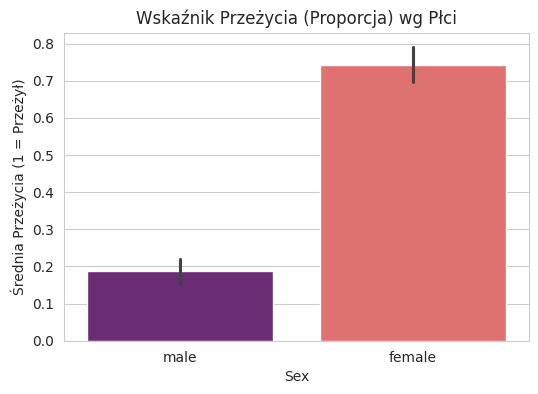

In [ ]:
sns.set_style("whitegrid") # Ustawienie estetycznego tła

plt.figure(figsize=(6, 4))
# x: Kategoria (Sex), y: Wartość (Survived), data: Nasz DataFrame
sns.barplot(x='Sex', y='Survived', data=df, palette='magma', hue='Sex', legend=False)
plt.title('Wskaźnik Przeżycia (Proporcja) wg Płci')
plt.ylabel('Średnia Przeżycia (1 = Przeżył)')
plt.show()

## 4.7. Wizualizacja - Wpływ Klasy Pasażerskiej

Wizualizacja zależności Pclass vs Survived również użyje ***sns.barplot***, aby pokazać, jak spada szansa przeżycia wraz z numerem klasy (spadek statusu SES).

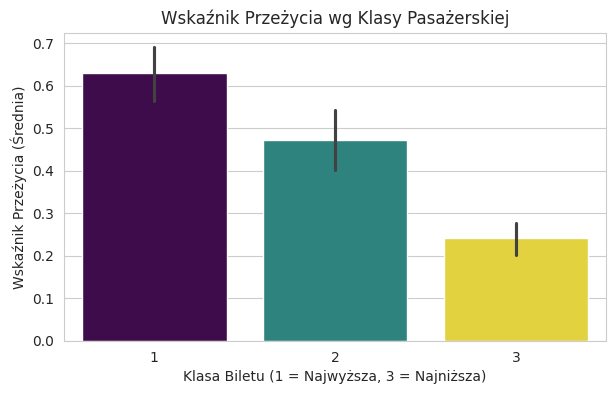

In [ ]:
plt.figure(figsize=(7, 4))

# Używamy barplot do obliczenia i wizualizacji średniej przeżycia dla każdej klasy
sns.barplot(
    x='Pclass',
    y='Survived',
    data=df,
    hue='Pclass',      # Jawne przypisanie hue, aby uniknąć deprecjacji
    palette='viridis', # Inna, kontrastowa paleta kolorów
    legend=False
)

plt.title('Wskaźnik Przeżycia wg Klasy Pasażerskiej')
plt.ylabel('Wskaźnik Przeżycia (Średnia)')
plt.xlabel('Klasa Biletu (1 = Najwyższa, 3 = Najniższa)')
plt.show()

##4.8. Wizualizacja - Analiza Dwuwymiarowa (Sex vs. Pclass vs. Survived)

**Co analizujemy:** Jak wskaźnik przeżycia (`Survived`) zmienia się w zależności od kombinacji **Płci** (`Sex`) oraz **Klasy Biletu** (`Pclass`).

<br>

**Jaki wykres:** Grupowy Bar Plot (`sns.barplot`). Idealny do graficznego udowodnienia, że status (klasa) i płeć działają łącznie, z priorytetem dla Kobiet z Klasy 1.

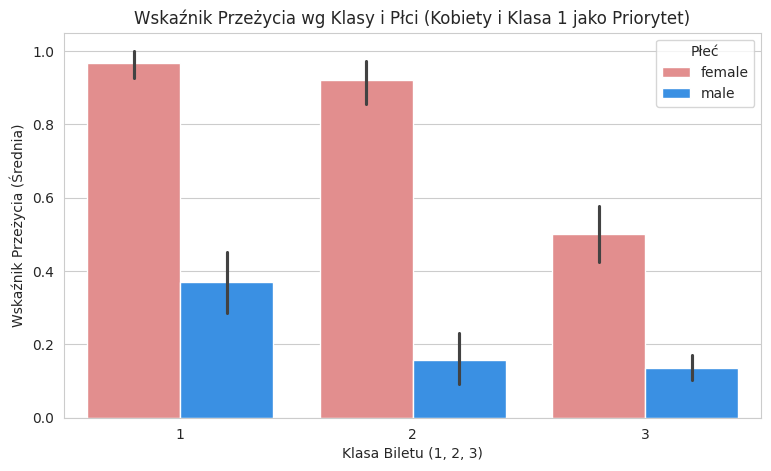

In [ ]:
plt.figure(figsize=(9, 5))

# X: Klasa Biletu, Y: Wskaźnik Przeżycia, Hue: Płeć
sns.barplot(
    x='Pclass',
    y='Survived',
    hue='Sex',  # Kluczowy parametr dzielący słupki (kolor)
    data=df,
    palette={'male': 'dodgerblue', 'female': 'lightcoral'} # Wyraźne kolory
)

plt.title('Wskaźnik Przeżycia wg Klasy i Płci (Kobiety i Klasa 1 jako Priorytet)')
plt.ylabel('Wskaźnik Przeżycia (Średnia)')
plt.xlabel('Klasa Biletu (1, 2, 3)')
plt.legend(title='Płeć')
plt.show()

##4.9. Wizualizacja - Wpływ Nowej Cechy (`Deck`)

**Co analizujemy:** Wpływ **Pokładu** (`Deck`) na Przeżycie (`Survived`). Sprawdzamy, czy informacja wydobyta z kolumny `Cabin` jest użyteczna.

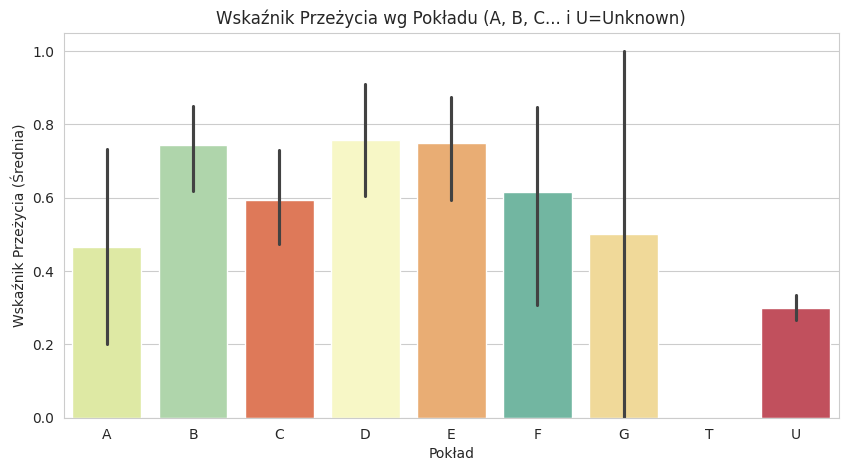

In [ ]:
plt.figure(figsize=(10, 5))

# Porównujemy wskaźnik przeżycia dla każdego Pokładu, włączając 'U' (Unknown)
# Sortowanie pokładów, aby 'U' było na końcu, co ułatwia interpretację
ordered_decks = df['Deck'].value_counts().index.sort_values()

sns.barplot(
    x='Deck',
    y='Survived',
    data=df,
    order=ordered_decks, # Używamy uporządkowania do czytelniejszego wykresu
    hue='Deck',
    palette='Spectral', # Wyrazista paleta dla wielu kategorii
    legend=False
)

plt.title('Wskaźnik Przeżycia wg Pokładu (A, B, C... i U=Unknown)')
plt.ylabel('Wskaźnik Przeżycia (Średnia)')
plt.xlabel('Pokład')
plt.show()

##4.10. Wizualizacja - Analiza Wieku (Age vs Survived)

**Co analizujemy:** Rozkład kolumny `Age` w kontekście kolumny `Survived`.

**Jaki wykres:** Histogram z nałożonym KDE (Kernel Density Estimate), używając parametru `hue='Survived'`.

**Dlaczego:** Histogram i KDE to najlepszy sposób na porównanie rozkładów zmiennej numerycznej w kontekście zmiennej binarnej (Przeżył/Nie Przeżył).

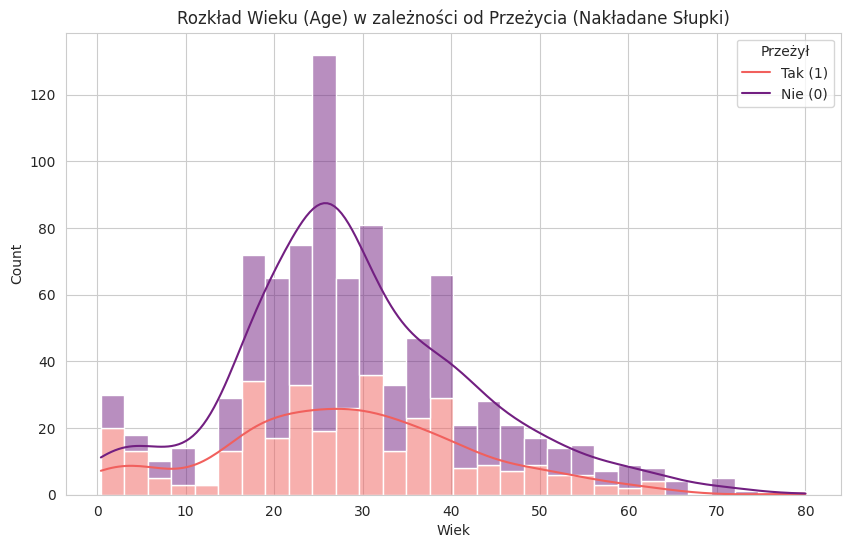

In [ ]:
plt.figure(figsize=(10, 6))

# Histogram z nałożonym KDE (dla gęstości)
# multiple='stack' pokazuje pełną liczebność pasażerów w danym przedziale
sns.histplot(
    data=df,
    x='Age',
    hue='Survived',      # Dzielimy histogram na dwie grupy (0 i 1)
    multiple='stack',    # Używamy nakładania słupków
    kde=True,            # Dodajemy wygładzoną krzywą gęstości (KDE)
    bins=30,             # Podział na 30 przedziałów
    palette='magma'
)

plt.title('Rozkład Wieku (Age) w zależności od Przeżycia (Nakładane Słupki)')
plt.xlabel('Wiek')
plt.legend(title='Przeżył', labels=['Tak (1)', 'Nie (0)'])
plt.show()

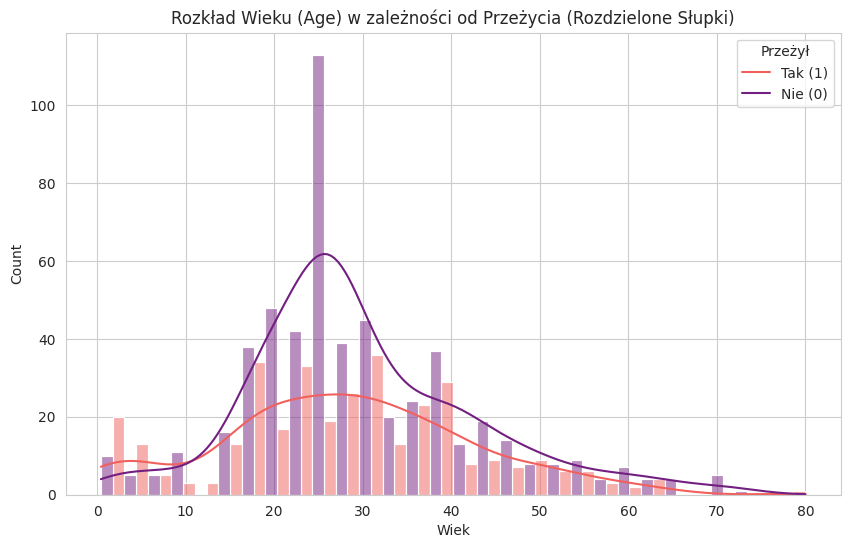

In [ ]:
plt.figure(figsize=(10, 6))

# Histogram z nałożonym KDE (dla gęstości)
# multiple='dodge' wizualnie lepiej oddziela rozkłady 'Przeżyli' i 'Zginęli'
sns.histplot(
    data=df,
    x='Age',
    hue='Survived',      # Dzielimy histogram na dwie grupy (0 i 1)
    multiple='dodge',    # Używamy rozdzielenia słupków
    kde=True,            # Dodajemy wygładzoną krzywą gęstości (KDE)
    bins=30,             # Podział na 30 przedziałów
    palette='magma'
)

plt.title('Rozkład Wieku (Age) w zależności od Przeżycia (Rozdzielone Słupki)')
plt.xlabel('Wiek')
plt.legend(title='Przeżył', labels=['Tak (1)', 'Nie (0)'])
plt.show()

##4.11.  Wizualizacja - Analiza Opłaty (Fare)

**Co analizujemy:** Rozkład kolumny `Fare`.

**Jaki wykres:** Box Plot (`sns.boxplot`).

**Dlaczego:** Box Plot wizualizuje kwartyle i **jednoznacznie** zaznacza Wartości Odstające (Outliers), graficznie potwierdzając, że kolumna jest silnie skośna i wymaga transformacji.

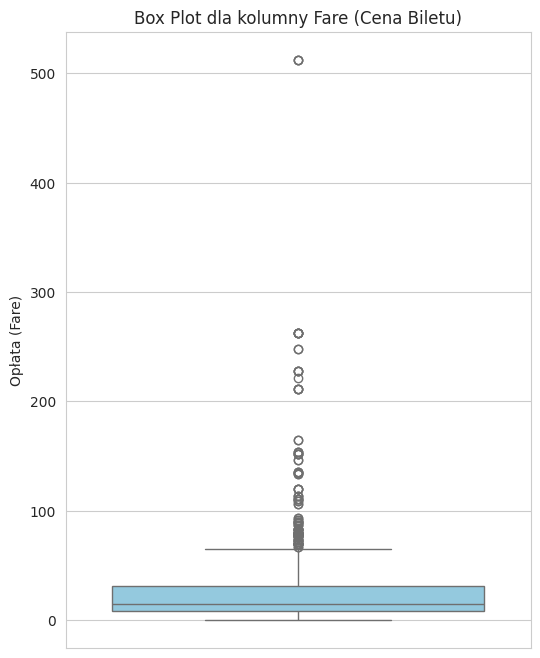

In [ ]:
plt.figure(figsize=(6, 8))

# Box plot idealnie wizualizuje rozrzut, kwartyle i Outliers
sns.boxplot(y=df['Fare'], color='skyblue')

plt.title('Box Plot dla kolumny Fare (Cena Biletu)')
plt.ylabel('Opłata (Fare)')
plt.show()

##4.12. Wizualizacja - Korelacjia (Heatmap)

**Co analizujemy:** Korelacje liniowe między wszystkimi cechami numerycznymi w DataFrame (w tym `Survived`).

**Jaki wykres:** Heatmap (`sns.heatmap`).

**Dlaczego:** Jest to najlepszy sposób na jednoczesną wizualizację wszystkich korelacji. Kolor i wartość numeryczna wskazują siłę i kierunek związku.

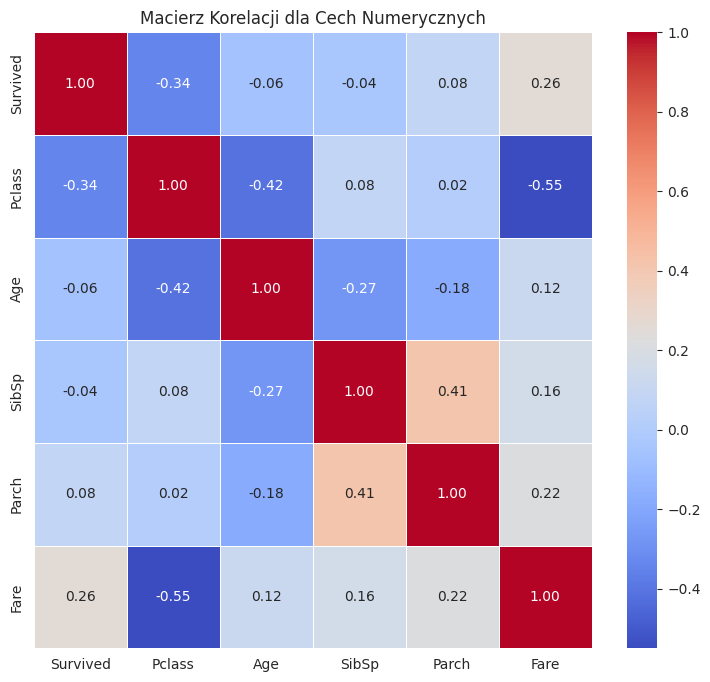

In [ ]:
# Najpierw upewniamy się, że mamy tylko kolumny numeryczne.
numeric_df_final = df.select_dtypes(include=['number'])
correlation_matrix = numeric_df_final.corr()

plt.figure(figsize=(9, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,          # Pokazuje numeryczne wartości korelacji na wykresie
    cmap='coolwarm',     # Standardowa paleta do korelacji (czerwony/niebieski)
    fmt=".2f",           # Formatowanie do 2 miejsc po przecinku
    linewidths=.5,       # Dodanie linii oddzielających dla estetyki
)

plt.title('Macierz Korelacji dla Cech Numerycznych')
plt.show()

##4.13. Wnioski z wizualizacji

### Płeć (Sex) i Klasa (Pclass) – Najsilniejsze Predyktory

Wykresy słupkowe z podziałem na płeć i klasę (`sns.barplot(x='Pclass', y='Survived', hue='Sex')`) dostarczyły najbardziej przekonujących dowodów:

- **Płeć była decydująca:** Wskaźnik przeżycia kobiet był drastycznie wyższy (około 74%) niż mężczyzn (około 19%) we wszystkich klasach. To graficznie udowadnia historyczną zasadę **"Kobiety i dzieci jako pierwsze"**.
- **Wpływ Statusu:** Istniała bardzo wyraźna hierarchia. Pasażerowie Klasy 1 mieli najwyższe szanse, a szanse spadały wraz z obniżeniem klasy (Klasa 3 miała najniższy wskaźnik przeżycia).
- **Połączenie czynników:** Najbezpieczniejszą grupą były Kobiety w Klasie 1 i 2 (ich wskaźnik przeżycia był bliski 100%), natomiast najmniej bezpieczną grupą byli Mężczyźni w Klasie 3 (najniższy słupek na wykresie).

<br>

### Pokład (Deck) – Weryfikacja Nowej Cechy
Analiza nowo utworzonej cechy Deck (Pokład, na podstawie kabiny) potwierdziła jej wartość predykcyjną:

- **Lokalizacja miała znaczenie:** Pokłady A, B, C i D (znajdujące się wyżej i bliżej szalup) wykazały wyższy wskaźnik przeżycia niż pokłady niższe.
- **Brak Kabiny (U):** Kategoria U (Unknown, czyli brak kabiny) miała wskaźnik przeżycia niski, co logicznie koreluje z pasażerami Klasy 3, którzy zginęli, potwierdzając, że informacja o braku kabiny jest ważna.

<br>

### Wiek (Age) – Rozkłady i Priorytety
Analiza histogramów ujawniła:

- **Priorytet dla Dzieci:** Słupki przedstawiające ocalonych były wyższe niż słupki przedstawiające ofiary w najmłodszych przedziałach wiekowych (0-5 lat), co jest silnym dowodem na priorytet ewakuacji dzieci.
- **Największa Liczba Ofiar:** Najwięcej osób zginęło w grupie młodych dorosłych (20-35 lat). W tym przedziale dominowały słupki "Zginęli", ponieważ była to najliczniejsza grupa na statku.

<br>

### Opłata (Fare) – Konieczność Transformacji
Wykres skrzynkowy (Box Plot) dla kolumny Fare jednoznacznie potwierdził statystyki opisowe:

- **Ekstremalna Skośność:** Wykres pokazał, że ponad 75% pasażerów zapłaciło stosunkowo niską cenę.
- **Wartości Odstające (Outliers):** Liczne, odseparowane punkty na górze są graficznym dowodem na to, że kolumna jest silnie skośna i musi zostać poddana **transformacji logarytmicznej** przed budową modelu, aby uniknąć zniekształceń.


In [ ]:
save_to_drive(df, 'titanic_eda', comment='rozpoczecie fazy eda')

Dane zapisane jako: /content/drive/MyDrive/datasets/titanic/titanic_eda_20251117_171023.csv
Historia zapisu dopisana do: /content/drive/MyDrive/datasets/titanic/save_history.txt


'/content/drive/MyDrive/datasets/titanic/titanic_eda_20251117_171023.csv'

In [ ]:
# Użyj funkcji, aby znaleźć najnowszą wersję 'eda'
latest_path = get_latest_data_version(
    project_name='titanic',
    data_type='eda'
)

if latest_path:
    # Wczytaj dane do głównego DataFrame
    df_current = pd.read_csv(latest_path)
    print(f"Dane wczytane.")
    print(f"Liczba wierszy: {len(df_current)} | Kolumn: {len(df_current.columns)}")
    df = df_current # Opcjonalnie: Ustawienie df jako głównej zmiennej roboczej
else:
    print("Nie znaleziono pliku 'eda'. Wymagane ręczne wczytanie 'raw'.")

Znaleziono najnowszą wersję: titanic_eda_20251117_171023.csv
Dane wczytane.
Liczba wierszy: 891 | Kolumn: 10


#5. Inżynieria Cech (Feature Engineering)

## 5.1. Tworzenie Cech Rodzinnych: `FamilySize` i `IsAlone`

Na podstawie analizy z Sekcji 4.1. wiemy, że cechy **`SibSp`** (rodzeństwo/małżonek) i **`Parch`** (rodzice/dzieci) są silnie skoncentrowane przy zerze (zero-inflated) i mają niską moc predykcyjną osobno. Połączenie ich w jedną, bardziej znaczącą cechę **`FamilySize`** jest kluczowe, ponieważ bycie w grupie ułatwiało ewakuację, ale bycie w **bardzo dużej** grupie utrudniało.

<br>

**Tworzone cechy:**
1.  **`FamilySize`**: Całkowita liczba członków rodziny na pokładzie (`SibSp + Parch + 1`, wliczając pasażera).
2.  **`IsAlone`**: Flaga binarna (0 lub 1) oznaczająca, czy pasażer podróżował sam (`FamilySize == 1`). Samotni pasażerowie mieli niższe szanse przeżycia, ponieważ priorytetem było ratowanie rodzin.

In [ ]:
# Obliczenie FamilySize: sumujemy rodzeństwo/małżonków, rodziców/dzieci i dodajemy 1 (samego pasażera)
df['FamilySize'] = 1 + df['SibSp'] + df['Parch']

# Tworzenie IsAlone (1, jeśli FamilySize == 1, 0, jeśli FamilySize > 1)
df.loc[df['FamilySize'] == 1, 'IsAlone'] = 1
df.loc[df['FamilySize'] > 1, 'IsAlone'] = 0

# Konwersja na typ integer (wymagane dla cech binarnych w modelowaniu)
df['IsAlone'] = df['IsAlone'].astype(int)

print("### Przykład Cech Rodzinnych (pierwsze 5 wierszy) ###")
print(df.head())

### Przykład Cech Rodzinnych (pierwsze 5 wierszy) ###
   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked Deck Title  \
0         0       3    male  22.0      1      0   7.2500        S    U    Mr   
1         1       1  female  38.0      1      0  71.2833        C    C   Mrs   
2         1       3  female  26.0      0      0   7.9250        S    U  Miss   
3         1       1  female  35.0      1      0  53.1000        S    C   Mrs   
4         0       3    male  35.0      0      0   8.0500        S    U    Mr   

   FamilySize  IsAlone  
0           2        0  
1           2        0  
2           1        1  
3           2        0  
4           1        1  


## 5.2. Kategoryzacja Wieku (`AgeGroup`) i Wybór Cechy

Wiek jest cechą ciągłą, ale jego wpływ na przeżycie często jest nieliniowy (np. 5-latek i 55-latek to różne priorytety). Kategoryzacja (binning) zwiększa siłę predykcyjną tej cechy w prostych modelach liniowych.

Przeprowadzamy testy dwóch logicznie uzasadnionych podziałów, a następnie używamy **Mutual Information (MI)**, aby obiektywnie wybrać najlepszą opcję.

In [ ]:
# implementacja AgeGroup1 (Podział 1: z mniejszymi grupami skrajnymi)
df.loc[df['Age'] < 15, 'AgeGroup1'] = 'Child'
df.loc[(df['Age'] >= 15) & (df['Age'] < 26), 'AgeGroup1'] = 'Young Adult'
df.loc[(df['Age'] >= 26) & (df['Age'] < 46), 'AgeGroup1'] = 'Adult'
df.loc[(df['Age'] >= 46) & (df['Age'] < 61), 'AgeGroup1'] = 'Mature'
df.loc[df['Age'] >= 61, 'AgeGroup1'] = 'Senior'

# implementacja AgeGroup2 (Podział 2: mniej grup, szerszy przedział dla Dorosłych)
df.loc[df['Age'] < 15, 'AgeGroup2'] = 'Child'
df.loc[(df['Age'] >= 15) & (df['Age'] < 25), 'AgeGroup2'] = 'Young Adult'
df.loc[(df['Age'] >= 25) & (df['Age'] < 51), 'AgeGroup2'] = 'Adult'
df.loc[df['Age'] >= 51, 'AgeGroup2'] = 'Senior'

print("Rozkład AgeGroup1:")
print(df['AgeGroup1'].value_counts(normalize=True))

print("\nRozkład AgeGroup2:")
print(df['AgeGroup2'].value_counts(normalize=True))

Rozkład AgeGroup1:
AgeGroup1
Adult          0.503928
Young Adult    0.289562
Child          0.092031
Mature         0.089787
Senior         0.024691
Name: proportion, dtype: float64

Rozkład AgeGroup2:
AgeGroup2
Adult          0.572391
Young Adult    0.263749
Child          0.092031
Senior         0.071829
Name: proportion, dtype: float64


###5.2.1 Obliczenie Mutual Information (MI)

**Mutual Information (Informacja Wzajemna)** mierzy, jak dużo informacji dostarcza jedna zmienna o drugiej (w naszym przypadku, ile informuje `AgeGroup` o `Survived`). Wyższa wartość MI oznacza silniejszą i bardziej użyteczną relację.

In [ ]:
# Utworzenie kopii ramek danych dla AgeGroup1 i AgeGroup2, gotowych do testu MI
# pd.get_dummies jest niezbędne, ponieważ MI działa na zmiennych numerycznych
age_group_features = pd.get_dummies(df[['AgeGroup1', 'AgeGroup2']], drop_first=True)

X_test = age_group_features
y = df['Survived']

# Import numpy dla kompatybilności z funkcją log1p używaną poniżej
import numpy as np
from sklearn.feature_selection import mutual_info_classif # Upewnienie się, że jest zaimportowane

# Osobna ocena dla każdej grupy
mi_age1 = mutual_info_classif(X_test.filter(regex='AgeGroup1'), y, random_state=42).mean()
mi_age2 = mutual_info_classif(X_test.filter(regex='AgeGroup2'), y, random_state=42).mean()

print(f"\nMutual Information dla AgeGroup1: {mi_age1:.4f}")
print(f"Mutual Information dla AgeGroup2: {mi_age2:.4f}")

# Wybierz najlepszą i stwórz finalną kolumnę 'AgeGroup'
if mi_age1 > mi_age2:
    print("\nZwycięzca: AgeGroup1 ma większą siłę predykcyjną! Wybrano AgeGroup1.")
    df['AgeGroup'] = df['AgeGroup1']
    # Dodatkowe potwierdzenie wybranego podziału:
    print("\nDo podziału 'Age' na 'AgeGroup' wykorzystamy:")
    print("- Dziecko: 0−14, Młody Dorosły: 15−25, Dorosły w Szczycie: 26−45, Dojrzały Wiek: 46−60, Senior: >60")
else:
    print("\nZwycięzca: AgeGroup2 ma większą siłę predykcyjną! Wybrano AgeGroup2.")
    df['AgeGroup'] = df['AgeGroup2']
    # Dodatkowe potwierdzenie wybranego podziału:
    print("\nDo podziału 'Age' na 'AgeGroup' wykorzystamy: Dzieci: 0-14, Młodzi Dorośli: 15-25, Dorośli: 25-50, Starsi: >50")

# Oczyszczenie DataFrame z tymczasowych kolumn AgeGroup1 i AgeGroup2
df.drop(columns=['AgeGroup1', 'AgeGroup2'], inplace=True)


Mutual Information dla AgeGroup1: 0.0086
Mutual Information dla AgeGroup2: 0.0038

Zwycięzca: AgeGroup1 ma większą siłę predykcyjną! Wybrano AgeGroup1.

Do podziału 'Age' na 'AgeGroup' wykorzystamy:
- Dziecko: 0−14, Młody Dorosły: 15−25, Dorosły w Szczycie: 26−45, Dojrzały Wiek: 46−60, Senior: >60


## 5.3. Transformacja Logarytmiczna `Fare` (`LogFare`)

### Problem Skośności
Analiza w Sekcji 4.1. wykazała, że kolumna **`Fare`** ma ekstremalną skośność w prawo z licznymi wartościami odstającymi (**Outliers**). Wartości te zniekształcają działanie modeli liniowych (np. Regresji Logistycznej), które zakładają normalny lub zbliżony do normalnego rozkład cech.

<br>

### Dlaczego Logarytm (`np.log1p`)?
Transformacja logarytmiczna ma za zadanie **zmniejszyć wpływ skrajnych wartości** i sprawić, że rozkład danych będzie **bardziej symetryczny** (bliższy rozkładowi normalnemu). Używamy `np.log1p(x)`, który oblicza $log(1+x)$, co jest standardową praktyką, ponieważ zapobiega problemom przy logarytmowaniu wartości zerowych (mieliśmy 1 brakujące `Fare` uzupełnione zerem w pierwotnym zbiorze).

In [ ]:
# Używam np.log1p(), aby uniknąć problemów z log(0),
# ponieważ dodaje 1 do każdej wartości przed obliczeniem logarytmu.
df['LogFare'] = np.log1p(df['Fare'])

# Sprawdzenie transformacji (pierwsze 5 wierszy)
print("### Wynik Transformacji Logarytmicznej Fare ###")
print(df[['Fare', 'LogFare']].head())

### Wynik Transformacji Logarytmicznej Fare ###
      Fare   LogFare
0   7.2500  2.110213
1  71.2833  4.280593
2   7.9250  2.188856
3  53.1000  3.990834
4   8.0500  2.202765


# 6. Przygotowanie Do Modelowania

## 6.1. Usuwanie Zastąpionych i Zredundowanych Cech

Usuwamy kolumny, które zostały zastąpione przez lepsze, bardziej predykcyjne cechy (`AgeGroup`, `LogFare`, `FamilySize`). Zachowanie ich doprowadziłoby do redundancji i problemu **multikolinearności** w modelu.

In [ ]:
# Usuwamy cechy, które zostały zastąpione lub wykorzystane do stworzenia lepszych cech.
columns_to_drop_final = ['SibSp', 'Parch', 'Age', 'Fare']

df.drop(columns=columns_to_drop_final, inplace=True)

print("### Kształt DataFrame po usunięciu cech ###")
print(df.shape)
print(df.columns.tolist())

### Kształt DataFrame po usunięciu cech ###
(891, 10)
['Survived', 'Pclass', 'Sex', 'Embarked', 'Deck', 'Title', 'FamilySize', 'IsAlone', 'AgeGroup', 'LogFare']


## 6.2. One-Hot Encoding (OHE) Cech Kategorycznych

Po usunięciu zbędnych cech i transformacji danych ciągłych, musimy przekształcić cechy nominalne i porządkowe w format zrozumiały dla modelu.

<br>

**One-Hot Encoding** polega na zamianie jednej kolumny kategorycznej na wiele nowych, binarnych kolumn. Każda kategoria staje się osobną kolumną z wartościami `1` (jeśli pasażer należy do tej kategorii) lub `0` (w przeciwnym razie).

<br>

**Użycie `drop_first=True`:** Jest to standardowa praktyka, która pozwala uniknąć problemu **multikolinearności** (redundancji informacyjnej). Jeśli mamy dwie kategorie (np. `Sex_male` i `Sex_female`), wystarczy nam jedna kolumna (`Sex_male`), ponieważ wartość `0` automatycznie oznacza `Sex_female`.

<br>

**Kolumny kategorialne do zakodowania:** `Title`, `Sex`, `Embarked`, `Pclass`, `Deck`, `AgeGroup`.

In [ ]:
# 1. Kolumny kategorialne do zakodowania
categorical_features = ['Title', 'Sex', 'Embarked', 'Pclass', 'Deck', 'AgeGroup']

# 2. Użycie get_dummies na wszystkich zmiennych kategorialnych
# df_final to nasz gotowy zbiór, ponieważ nie zawiera już cech pośrednich (usunięte w 6.1)
df_final = pd.get_dummies(df, columns=categorical_features, drop_first=True)

# Sprawdzenie kształtu i typów danych (powinno być wiele nowych kolumn binarnych)
print("### Kształt DataFrame po One-Hot Encoding ###")
print(df_final.shape)

### Kształt DataFrame po One-Hot Encoding ###
(891, 25)


In [ ]:
df_final.head()


,Survived,FamilySize,IsAlone,LogFare,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Sex_male,Embarked_Q,...,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_U,AgeGroup_Child,AgeGroup_Mature,AgeGroup_Senior,AgeGroup_Young Adult
0,0,2,0,2.110213,False,True,False,False,True,False,...,False,False,False,False,False,True,False,False,False,True
1,1,2,0,4.280593,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1,1,1,2.188856,True,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,1,2,0,3.990834,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,0,1,1,2.202765,False,True,False,False,True,False,...,False,False,False,False,False,True,False,False,False,False


In [ ]:
save_to_drive(df_final, 'titanic_model', comment='Data is Ready')

Dane zapisane jako: /content/drive/MyDrive/datasets/titanic/titanic_model_20251117_171446.csv
Historia zapisu dopisana do: /content/drive/MyDrive/datasets/titanic/save_history.txt


'/content/drive/MyDrive/datasets/titanic/titanic_model_20251117_171446.csv'

In [ ]:
latest_path = get_latest_data_version(project_name='titanic', data_type='model')

if latest_path:
    # Wczytaj dane do głównego DataFrame
    df_current = pd.read_csv(latest_path)
    print(f"Dane wczytane. Nowa praca zaczyna się od {len(df_current)} wierszy.")
    df = df_current # Opcjonalnie: Ustawienie df jako głównej zmiennej roboczej
else:
    print("Nie znaleziono pliku 'clean'. Wymagane ręczne wczytanie 'raw'.")

Znaleziono najnowszą wersję: titanic_model_20251117_171446.csv
Dane wczytane. Nowa praca zaczyna się od 891 wierszy.


## 6.3. Przygotowanie Modelu - Podział na Dane Treningowe i Testowe

Przed rozpoczęciem budowy modelu konieczne jest podzielenie finalnego zbioru danych na dwie części:

1.  **Zbiór Treningowy (`X_train`, `y_train`):** Używany przez algorytm do nauki wzorców i współczynników.
2.  **Zbiór Testowy (`X_test`, `y_test`):** Używany do ostatecznej oceny i weryfikacji modelu. Model musi zobaczyć **nowe, nieznane dane** z tego zbioru, abyśmy mogli ocenić, jak dobrze generalizuje (działa) na realnym świecie.

<br>

**Dlaczego `random_state=42`?** Ustawienie tego parametru gwarantuje, że podział danych będzie **zawsze taki sam** przy każdym uruchomieniu notebooka, co jest niezbędne dla powtarzalności Twoich wyników (zgodnie z zasadą **Rozwój i Mistrzostwo**).

In [ ]:
from sklearn.model_selection import train_test_split # Upewniamy się, że funkcja jest zaimportowana

# 1. Definiuję X (cechy) i y (zmienna docelowa)
# Używamy df_final po One-Hot Encoding, ale zakładam, że usunąłeś kolumny pośrednie wcześniej.
# WAŻNE: W tym miejscu musimy użyć DataFrame'u po One-Hot Encoding.
# Jeśli Twój finalny DataFrame po OHE nazywa się 'df_final', użyj go zamiast 'df'.

# W tym kodzie X musi być zdefiniowane jako df_final bez Survived:
X = df_final.drop('Survived', axis=1) # Cechy
y = df_final['Survived']              # Zmienna docelowa

# 2. Podział (np. 80% na trening, 20% na test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2, # 20% na test
    random_state=42 # Ważne dla powtarzalności Twojego wyniku
)

print(f"Kształt X (cechy do modelowania): {X.shape}")
print("-" * 30)
print(f"X_train (cechy treningowe): {X_train.shape}")
print(f"X_test (cechy testowe): {X_test.shape}")
print(f"y_train (etykiety treningowe): {y_train.shape}")
print(f"y_test (etykiety testowe): {y_test.shape}")



Kształt X (cechy do modelowania): (891, 24)
------------------------------
X_train (cechy treningowe): (712, 24)
X_test (cechy testowe): (179, 24)
y_train (etykiety treningowe): (712,)
y_test (etykiety testowe): (179,)


#7. Modelowanie

## 7.1. Regresja Logistyczna (Logistic Regression)

**Wybrany model:** Regresja Logistyczna (Logistic Regression). Jest to doskonały wybór dla pierwszego modelu klasyfikacyjnego, ponieważ jest szybki, wydajny i, co najważniejsze, **wysoce interpretowalny**.

**Cel:** Użycie Regresji Logistycznej do przewidzenia zmiennej binarnej (`Survived`).


In [ ]:
# Utworzenie i Trenowanie Modelu
# max_iter=200 jest użyte, by zapewnić konwergencję algorytmu na małym zbiorze danych
model = LogisticRegression(random_state=42, max_iter=200)

# Trenowanie modelu na zbiorze treningowym
model.fit(X_train, y_train)

# Predykcja
# Używamy wytrenowanego modelu do przewidywania etykiet na zbiorze testowym
y_pred = model.predict(X_test)

# Ocena Modelu
print("### Wyniki Oceny Modelu Regresji Logistycznej ###")
print("-" * 45)
print(f"Dokładność (Accuracy): {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

### Wyniki Oceny Modelu Regresji Logistycznej ###
---------------------------------------------
Dokładność (Accuracy): 0.8212

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.85      0.85       105
           1       0.78      0.78      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.82      0.82      0.82       179



## 7.2. Omówienie Classification Report (Interpretacja Metryk)

Raport klasyfikacji dostarcza szczegółowych informacji o wydajności modelu na zbiorze testowym, analizując wyniki dla każdej klasy (0 = Zginął, 1 = Przeżył).

- **Support (Wsparcie)**: Liczba rzeczywistych obserwacji w zbiorze testowym dla każdej klasy (105 osób nie przeżyło, 74 przeżyły).

- **Accuracy (Dokładność)**: **82.12%** wszystkich przewidywań modelu (przeżył/nie przeżył) było poprawnych. To ogólny wskaźnik sukcesu.

- **Precision (Precyzja)**:
    - Dla klasy **0 (Zginął)**: **85%**. Gdy model przewidział, że ktoś zginął, w 85% przypadków miał rację.
    - Dla klasy **1 (Przeżył)**: **78%**. Gdy model przewidział, że ktoś przeżył, w 78% przypadków miał rację.

- **Recall (Czułość)**:
    - Dla klasy **0 (Zginął)**: **85%**. Wśród wszystkich, którzy faktycznie zginęli, model poprawnie ich zidentyfikował w 85% przypadków.
    - Dla klasy **1 (Przeżył)**: **78%**. Wśród wszystkich, którzy faktycznie przeżyli, model poprawnie ich zidentyfikował w 78% przypadków.

- **F1-Score**: Średnia harmoniczna (równowaga) między Precision i Recall. Wskaźnik ten jest szczególnie użyteczny, gdy klasy są nierówne, pokazując dobrą równowagę (0.85 i 0.78).

**Wniosek:** Model jest nieznacznie lepszy w przewidywaniu zgonów (Klasa 0) niż przeżyć (Klasa 1), co jest typowe dla tego zbioru danych, gdzie klasa 0 jest dominująca.

## 7.3. Analiza Współczynników Modelu (Feature Importance)

W modelu Regresji Logistycznej, **współczynniki** (`coefficients`) wskazują siłę i kierunek wpływu każdej cechy na zmienną docelową:

- **Współczynnik dodatni (+)**: Wzrost wartości cechy zwiększa log-szansę przeżycia.
- **Współczynnik ujemny (-)**: Wzrost wartości cechy zmniejsza log-szansę przeżycia.

Analiza tych współczynników jest kluczowa dla interpretowalności i zrozumienia, dlaczego model podjął określoną decyzję.

In [ ]:
# Wytrenowany model to 'model' (z poprzedniego kroku)
# Kolumny użyte do treningu są w X_train.columns

# Tworzenie DataFrame ze współczynnikami i ich nazwami cech
coefficients = pd.DataFrame({
    'Cecha': X_train.columns,
    'Współczynnik (Coeff)': model.coef_[0]
})

# Dodanie wartości bezwzględnej dla łatwego sortowania siły wpływu
coefficients['Abs_Coeff'] = abs(coefficients['Współczynnik (Coeff)'])
coefficients = coefficients.sort_values(by='Abs_Coeff', ascending=False)

print("\nZnaczenie Cech w Modelu (TOP 10 wg Siły Wpływu):\n")
print(coefficients.head(10).to_string(index=False)) # Użycie to_string(index=False) dla czystego widoku


Znaczenie Cech w Modelu (TOP 10 wg Siły Wpływu):

          Cecha  Współczynnik (Coeff)  Abs_Coeff
       Title_Mr             -2.131989   2.131989
     Title_Rare             -1.248052   1.248052
         Deck_E              1.159628   1.159628
         Deck_G             -0.894309   0.894309
       Sex_male             -0.874127   0.874127
 AgeGroup_Child              0.833081   0.833081
         Deck_U             -0.753401   0.753401
      Title_Mrs              0.742142   0.742142
         Deck_D              0.721320   0.721320
AgeGroup_Mature             -0.710286   0.710286


# 8. Podsumowanie Końcowe

# Titanic: Analiza Czynników Przeżycia i Pierwszy Model Klasyfikacyjny (Accuracy 82.12%)

<br>

## 1. Wstęp (Cel Projektu):
Celem tego projektu było przeprowadzenie Eksploracyjnej Analizy Danych (EDA) na zbiorze danych Titanic, zidentyfikowanie kluczowych czynników wpływających na przeżywalność, a następnie zbudowanie prostego, ale skutecznego modelu predykcyjnego.

<br>

## 2. Kluczowe Odkrycia z EDA (Analiza Danych):

<br>

### 2.1. W trakcie analizy danych (EDA) potwierdziłem kluczowe wnioski historyczne:

- **Płeć była decydująca:** Wskaźnik przeżycia kobiet był drastycznie wyższy (około 74%) niż mężczyzn (około 19%) we wszystkich klasach. To graficznie udowadnia historyczną zasadę **"Kobiety i dzieci jako pierwsze"**.
- **Wpływ Statusu:** Istniała bardzo wyraźna hierarchia. Pasażerowie Klasy 1 mieli najwyższe szanse, a szanse spadały wraz z obniżeniem klasy (Klasa 3 miała najniższy wskaźnik przeżycia).
- **Połączenie czynników:** Najbezpieczniejszą grupą były Kobiety w Klasie 1 i 2 (ich wskaźnik przeżycia był bliski 100%), natomiast najmniej bezpieczną grupą byli Mężczyźni w Klasie 3 (najniższy słupek na wykresie).
- **Lokalizacja miała znaczenie:** Nowo utworzona cecha **Deck** (Pokład) wykazała, że lokalizacja na pokładach A, B, C i D (bliżej szalup) korelowała z wyższym wskaźnikiem przeżycia.
- **Priorytet dla Dzieci:** Analiza wieku potwierdziła priorytet ewakuacji dzieci (0-5 lat).
- **Nowe Cechy (Feature Engineering):** Stworzono mocniejsze cechy: `FamilySize`, binarną flagę **`IsAlone`**, skategoryzowaną **`AgeGroup`**, wyodrębniony **`Title`** oraz przekształconą logarytmicznie **`LogFare`**.

<br>

### 2.2. Analiza współczynników modelu (Regresji Logistycznej) wykazała, że najsilniejszy wpływ na wynik miały czynniki społeczne i lokalizacyjne:

- Cechy wskazujące na bycie dorosłym mężczyzną (np. `Title_Mr`) miały najsilniejszy **negatywny wpływ** na szanse przeżycia (współczynnik ok. -2.13).
- Cechy wskazujące na bycie kobietą, wysoką klasę oraz lokalizację na wyższych pokładach (np. `Deck_E`) miały najsilniejszy **pozytywny wpływ** (współczynnik ok. +1.16 dla Deck_E).

<br>

## 3. Modelowanie i Rezultaty (Regresja Logistyczna):

Po przygotowaniu i zakodowaniu danych, zbudowałem prosty model klasyfikacyjny – Regresję Logistyczną – którego celem było przewidzenie, czy dany pasażer przeżył katastrofę.

- **Wynik Modelu:** Model osiągnął **82.12% dokładności (Accuracy)** na zbiorze testowym.
- **Wnioski z Oceny:** Analiza `Classification Report` (Precision i Recall) pokazała, że model jest nieznacznie silniejszy w poprawnym przewidywaniu zgonów (Klasa 0: Precision 85%) niż w poprawnym przewidywaniu przeżyć (Klasa 1: Precision 78%).

<br>

## 4. Dalsze Kroki (Rozwój i Mistrzostwo)

Aby poprawić ten wynik, dalsze prace powinny koncentrować się na:
1.  **Regularyzacja:** Zastosowanie regularyzacji L1 lub L2 w modelu `LogisticRegression` w celu ograniczenia wpływu cech i zapobiegania overfittingowi.
2.  **Zaawansowane Modele:** Przetestowanie silniejszych algorytmów, takich jak **Random Forest Classifier** lub **Gradient Boosting**, które często dają lepsze wyniki na tak przetworzonych zbiorach danych.
3.  **Optymalizacja Hiperparametrów:** Użycie `GridSearchCV` lub `RandomizedSearchCV` do znalezienia optymalnych hiperparametrów dla wybranego algorytmu.